# EAI Assignment 04 Training a Model
Ranzmaier Treml

## Data Analysis

We checked for the raw sequence lengths in the gesture dataset before training.

The classes do not have the same mean length.
Because of that, we decided to resample every recording to a fixed length so the CNN can train on a consistent input shape.


In [2]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
rows = []
for path in sorted(glob.glob(os.path.join('data', '*.csv'))):
    df = pd.read_csv(path)
    rows.append((os.path.basename(path), str(df['label'].iloc[0]).strip(), len(df)))

else:
    d = pd.DataFrame(rows, columns=['file', 'label', 'timesteps'])
    means = d.groupby('label')['timesteps'].mean().sort_values()
    print('Mean timesteps per label:')
    print(means.round(2).to_string())

Mean timesteps per label:
label
C    30.08
A    47.77
X    50.01
B    59.27


In [ ]:
# using accelerometer + gyroscope and magnetometer (9-axis)
features = [
    "accel_x","accel_y","accel_z",
    "gyro_x","gyro_y","gyro_z",
    "mag_x","mag_y","mag_z"
]

# reuse from A02 TODO: scipy resample exists 
def resample_recording(df, num_points):
    """ Resample the recording to a fixed number of points using linear interpolation."""
    n = len(df)

    old_t = np.linspace(0, 1, n)
    new_t = np.linspace(0, 1, num_points)

    resampled = {}

    for col in features:
        f = interp1d(old_t, df[col].values, kind="linear")
        resampled[col] = f(new_t)

    return pd.DataFrame(resampled)

# converting our labels to integers
label_map = {"A":0, "B":1, "C":2, "X":3}

X_sequences = []
y_labels = []

# getting all the samples from the files
for file in os.listdir('data'):
    if not file.endswith(".csv"):
        continue

    df = pd.read_csv(os.path.join('data', file))

    label_char = df["label"].iloc[0] # A,B,C,X
    label = label_map[label_char] # assigning the label - lol

    # getting to one coherent shape at the end for training - otherwise not really possible
    df_resampled = resample_recording(df, 50)

    X = df_resampled[features].values
    X_sequences.append(X)
    y_labels.append(label)

# converting to array 
X_seq = np.array(X_sequences)
y_seq = np.array(y_labels)

print("Shape:", X_seq.shape)

Shape: (400, 50, 9)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# Normalize with TRAIN-only stats (apply same transform to val/test)
mean = X_train.mean(axis=(0,1))
std = X_train.std(axis=(0,1)) + 1e-8
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

#show_dist('Train', y_train)
#show_dist('Val', y_val)
#show_dist('Test', y_test)

# 0.7, 0.15, 0.15 split - use that in GAI all the time lol
X_train.shape, X_test.shape, X_val.shape

((280, 50, 9), (60, 50, 9), (60, 50, 9))

In [ ]:
# small CNN 
model = tf.keras.Sequential([
    layers.Input(shape=(50, 9)), # 50 timesteps, 9 features

    layers.Conv1D(4, 3, activation='relu'), 
    layers.GlobalAveragePooling1D(),

    layers.Dense(8, activation='relu'), 
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print('Model params:', model.count_params())

Model params: 188


Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2607 - loss: 1.4691 - val_accuracy: 0.2167 - val_loss: 1.4548
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2643 - loss: 1.4693 - val_accuracy: 0.2167 - val_loss: 1.4283
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2393 - loss: 1.4262 - val_accuracy: 0.2500 - val_loss: 1.4117
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2286 - loss: 1.4084 - val_accuracy: 0.2500 - val_loss: 1.4042
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3143 - loss: 1.3936 - val_accuracy: 0.2833 - val_loss: 1.3961
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2643 - loss: 1.3961 - val_accuracy: 0.2833 - val_loss: 1.3903
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3036 - loss: 1.3768 - val_accuracy: 0.3000 - val_loss: 1.3847
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3107 - loss: 1.3753 - val_accuracy: 0.3000 - val_loss

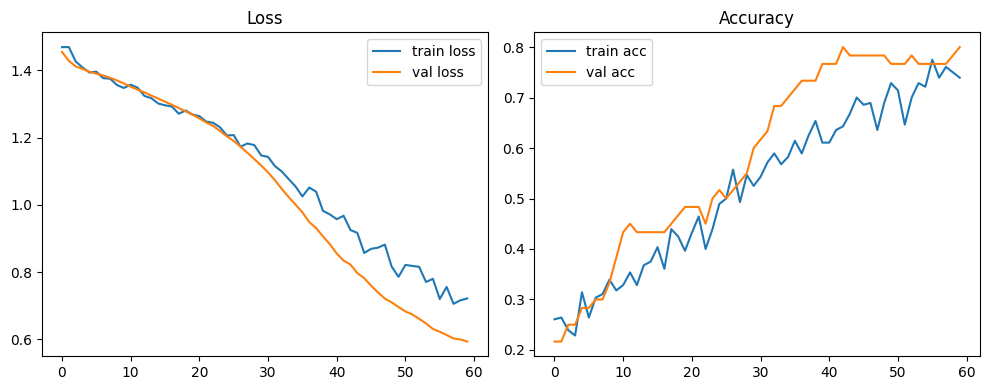

In [7]:
# Train and capture history for plotting
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val)
)

# Plot training/validation loss and accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 4)          │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 4)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566 (2.21 KB)

 Trainable params: 188 (752.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 378 (1.48 KB)

None


Parameter because of adam

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc) 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8333 - loss: 0.6407
Test accuracy: 0.8333333134651184


In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpocwhpqb0/assets


INFO:tensorflow:Assets written to: /tmp/tmpocwhpqb0/assets


Saved artifact at '/tmp/tmpocwhpqb0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  281470781941392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281470781942352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281470781944464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281470781941968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281470781943888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  281470781945232: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1778155043.066381   23677 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778155043.066844   23677 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778155043.068170   23677 reader.cc:83] Reading SavedModel from: /tmp/tmpocwhpqb0
I0000 00:00:1778155043.068437   23677 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778155043.068447   23677 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpocwhpqb0
I0000 00:00:1778155043.073199   23677 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778155043.073715   23677 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778155043.090499   23677 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpocwhpqb0
I0000 00:00:1778155043.094541   23677 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 26378 microseconds.
I0000 00:00:1778155043.152554   23677

In [11]:
# check size of tflite model
print("TFLite model size (bytes):", len(tflite_model))

TFLite model size (bytes): 4252
